По открытым данным о заведениях общественного питания в Москве требуется провести исследование рынка.

## Описание располагаемых данных

Каждая запись характеризуется следующим набором признаков:

|Признак|Описание|
|------:|:-------|
|`id` | идентификатор объекта|
|`object_name` | название объекта общественного питания|
|`chain` | сетевой ресторан|
|`object_type` | тип объекта общественного питания|
|`address` | адрес|
|`number` |  количество посадочных мест|

## Задание
### Шаг 1. Загрузите данные и подготовьте их к анализу

- Загрузить данные о заведениях общественного питания Москвы.
- Проверить корректность установленных типов данных.
- Проверить наличие пропущенных значений и дубликатов.

### Шаг 2. Разведочный анализ данных
- Исследовать соотношение типов объектов общественного питания по количеству. Построить график.
- Исследовать соотношение сетевых и несетевых заведений по количеству. Построить график.
- Установить для какого типа объекта общественного питания характерно сетевое распространение.
- Что характерно для сетевых заведений: много заведений с небольшим числом посадочных мест в каждом или мало заведений с большим количеством посадочных мест?
- Для каждого типа объекта общественного питания найти среднее количество посадочных мест. Какой тип предоставляет в среднем самое большое количество посадочных мест? Построить графики.
- Выделить в отдельный столбец информацию об улице из столбца `address`.
- Построить график топ-10 улиц по количеству объектов общественного питания.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [113]:
#загрузка данных
df = pd.read_csv('/content/restaurant.csv')
df

,id,object_name,chain,object_type,address,number
0,151635,СМЕТАНА,нет,кафе,"город Москва, улица Егора Абакумова, дом 9",48
1,77874,Родник,нет,кафе,"город Москва, улица Талалихина, дом 2/1, корпус 1",35
2,24309,Кафе «Академия»,нет,кафе,"город Москва, Абельмановская улица, дом 6",95
3,21894,ПИЦЦЕТОРИЯ,да,кафе,"город Москва, Абрамцевская улица, дом 1",40
4,119365,Кафе «Вишневая метель»,нет,кафе,"город Москва, Абрамцевская улица, дом 9, корпус 1",50
...,...,...,...,...,...,...
15361,208537,Шоколадница,да,кафе,"город Москва, 3-й Крутицкий переулок, дом 18",50
15362,209264,Шоколадница,да,кафе,"город Москва, улица Земляной Вал, дом 33",10
15363,209186,Шоколадница,да,кафе,"город Москва, улица Земляной Вал, дом 33",20
15364,221900,Шоколадница,да,кафе,"город Москва, поселение Московский, Киевское ш...",36


In [114]:
#поиск дублей
df.duplicated().sum()
df.drop(columns='id').duplicated()
df.loc[df.drop(columns='id').duplicated()].index
index_del = df.loc[df.drop(columns='id').duplicated()].index
df.drop(index=index_del)

df_new = df.drop(columns = 'id').drop_duplicates()

In [115]:
df_new.merge(df[['id', 'object_name', 'address']],
             on=['object_name', 'address'],
             how='inner')

,object_name,chain,object_type,address,number,id
0,СМЕТАНА,нет,кафе,"город Москва, улица Егора Абакумова, дом 9",48,151635
1,Родник,нет,кафе,"город Москва, улица Талалихина, дом 2/1, корпус 1",35,77874
2,Кафе «Академия»,нет,кафе,"город Москва, Абельмановская улица, дом 6",95,24309
3,ПИЦЦЕТОРИЯ,да,кафе,"город Москва, Абрамцевская улица, дом 1",40,21894
4,Кафе «Вишневая метель»,нет,кафе,"город Москва, Абрамцевская улица, дом 9, корпус 1",50,119365
...,...,...,...,...,...,...
15823,Шоколадница,да,кафе,"город Москва, улица Земляной Вал, дом 33",10,209264
15824,Шоколадница,да,кафе,"город Москва, улица Земляной Вал, дом 33",10,209186
15825,Шоколадница,да,кафе,"город Москва, улица Земляной Вал, дом 33",20,209264
15826,Шоколадница,да,кафе,"город Москва, улица Земляной Вал, дом 33",20,209186


In [129]:
#УДАЛЕНИЕ ДУБЛЕЙ С ОСТАВЛЕНИЕМ ПЕРВЫХ ДУБЛЕЙ И признака id

#удаляем признак id  и находим индексы ВСЕХ дублей
index_all_dupl = df.loc[df.drop(columns='id').duplicated()].index

#удаляем признак id. отбираем датафрейм с дублями.удаляем все дубли, кроме "первых".забираем индекс
index_first_dupl = df.drop(columns='id').loc[df.drop(columns='id').duplicated()].drop_duplicates().index

#индексы удаленных дублей
index_del_dupl = set(index_all_dupl).difference(set(index_first_dupl))

20

In [144]:
#итоговый датафрейм
df_new = df.drop(index=index_del_dupl)

In [3]:
# Выделить в отдельный столбец информацию об улице из столбца address.
# Построить график топ-10 улиц по количеству объектов общественного питания.
lst_type_street = ['улица', 'шоссе', 'бульвар',
                   'переулок', 'проезд', 'проспект', 'набережная',
                   'площадь', 'аллея', 'микрорайон', 'город Зеленоград',
                   'линия', 'квартал', 'деревня', 'посёлок',
                   'километр', 'село', 'тупик', 'территория',
                   'просек']
lst_street = list()

d = 'город Москва, улица Егора Абакумова, дом 9'
list(map(str.strip, d.split(',')))

for address in list(map(str.strip, d.split(','))):
    for street in lst_type_street:
        if address.find(street)>=0:
            lst_street.append(address)

In [4]:
d
lst_type_street

['улица',
 'шоссе',
 'бульвар',
 'переулок',
 'проезд',
 'проспект',
 'набережная',
 'площадь',
 'аллея',
 'микрорайон',
 'город Зеленоград',
 'линия',
 'квартал',
 'деревня',
 'посёлок',
 'километр',
 'село',
 'тупик',
 'территория',
 'просек']

In [5]:
def get_street(address_item, lst_type_street)->str:
    """
    Функция по адресу возвращает название улицы.
    Передаем два параметра: строку с адресом и типы улиц
    """

    address_element = ''
    street = ''

    for address_element in list(map(str.strip, address_item.split(','))):
        for street in lst_type_street:
            if address_element.find(street)>=0:
                return address_element
    return 'Тип улицы не распознан'

In [6]:
get_street('город Москва, 3-й Крутицкий тупик, дом 18', lst_type_street)

'3-й Крутицкий тупик'

In [7]:
# если функция, которая применяется к серии, кроме самой среии, имеет еще параметры,
# то эти параметры перечисляются в параметры args метода apply виде кортежа
df['street'] = df['address'].apply(get_street, args=(lst_type_street,))

In [8]:
df[['address', 'street']]

,address,street
0,"город Москва, улица Егора Абакумова, дом 9",улица Егора Абакумова
1,"город Москва, улица Талалихина, дом 2/1, корпус 1",улица Талалихина
2,"город Москва, Абельмановская улица, дом 6",Абельмановская улица
3,"город Москва, Абрамцевская улица, дом 1",Абрамцевская улица
4,"город Москва, Абрамцевская улица, дом 9, корпус 1",Абрамцевская улица
...,...,...
15361,"город Москва, 3-й Крутицкий переулок, дом 18",3-й Крутицкий переулок
15362,"город Москва, улица Земляной Вал, дом 33",улица Земляной Вал
15363,"город Москва, улица Земляной Вал, дом 33",улица Земляной Вал
15364,"город Москва, поселение Московский, Киевское ш...",Киевское шоссе


In [9]:
df.loc[df.street == 'Тип улицы не распознан']

,id,object_name,chain,object_type,address,number,street
8647,142771,Пиццерия,нет,кафе,"город Москва, поселение Щаповское, вблизи дере...",22,Тип улицы не распознан
8660,145255,Drive,нет,кафе,"город Москва, поселение Щаповское, вблизи пос....",16,Тип улицы не распознан
11782,185884,Кафе,нет,кафе,"город Москва, поселение Марушкинское, вблизи д...",16,Тип улицы не распознан
11785,188405,Оби-Рахмат,нет,кафе,"город Москва, поселение Вороновское, вблизи де...",30,Тип улицы не распознан


In [10]:
df.loc[11782]['address']

'город Москва, поселение Марушкинское, вблизи деревни Крекшино, дом 14Б/Н'

In [13]:
df.head(2)

,id,object_name,chain,object_type,address,number,street
0,151635,СМЕТАНА,нет,кафе,"город Москва, улица Егора Абакумова, дом 9",48,улица Егора Абакумова
1,77874,Родник,нет,кафе,"город Москва, улица Талалихина, дом 2/1, корпус 1",35,улица Талалихина


In [30]:
#Построить график топ-10 улиц по количеству объектов общественного питания.

df_to_plot = df.groupby('street').agg(count_object = ('id', 'count'))\
.reset_index()\
.sort_values(by='count_object', ascending=False).head(10)

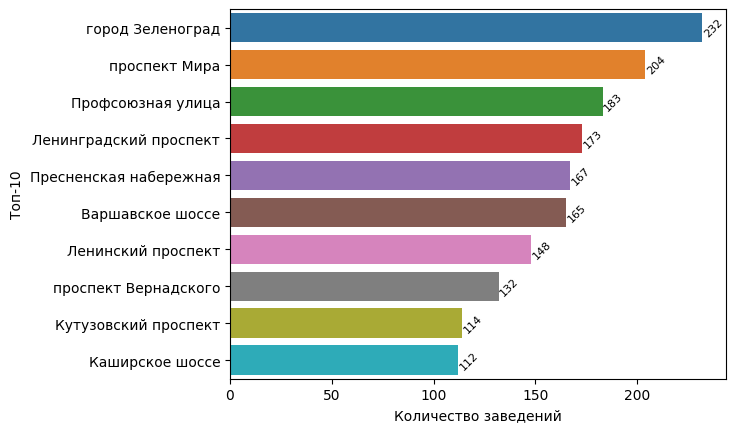

In [40]:
ax = sns.barplot(data=df_to_plot,
                 x='count_object',
                 y='street');
ax.set_xlabel('Количество заведений')
ax.set_ylabel('Топ-10')
ax.bar_label(ax.containers[0], fontsize=8, rotation=45); #указываем надписи на столбиками + размер шрифта

<Axes: xlabel='street', ylabel='count'>

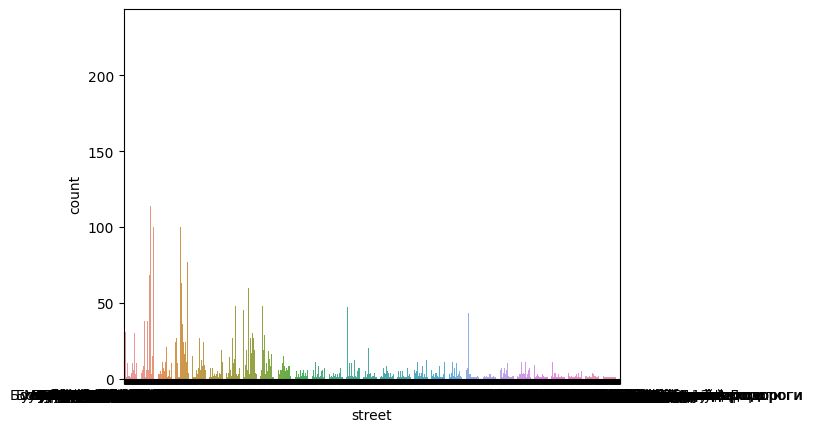

In [32]:
sns.countplot(data=df,
              x='street')

In [27]:
df.groupby('street').object_name.count()

street
1-й Автозаводский проезд     3
1-й Амбулаторный проезд      2
1-й Балтийский переулок      1
1-й Басманный переулок       1
1-й Ботанический проезд      1
                            ..
улица Юности                 3
улица Юных Ленинцев         22
улица Яблочкова              7
шоссе Фрезер                 1
шоссе Энтузиастов           47
Name: object_name, Length: 1955, dtype: int64

In [25]:
df.groupby('street').ngroups

1955

In [65]:
df.groupby('street').get_group('город Зеленоград')

,id,object_name,chain,object_type,address,number,street
1386,22331,СТОЛОВАЯ МИЭТ,нет,столовая,"город Москва, город Зеленоград, улица Юности, ...",56,город Зеленоград
1405,20199,ЭТО,нет,кафе,"город Москва, город Зеленоград, корпус 401",35,город Зеленоград
1406,68113,Френдс,нет,кафе,"город Москва, город Зеленоград, корпус 435",34,город Зеленоград
1407,20105,Кафе «Граф Монте-Кристо»,нет,кафе,"город Москва, город Зеленоград, корпус 436",40,город Зеленоград
1408,22982,Альфорно,нет,кафе,"город Москва, город Зеленоград, корпус 438",49,город Зеленоград
...,...,...,...,...,...,...,...
14478,211676,Никольский,нет,ресторан,"город Москва, город Зеленоград, корпус 532",120,город Зеленоград
14479,220992,Dolce crema,нет,предприятие быстрого обслуживания,"город Москва, город Зеленоград, Панфиловский п...",0,город Зеленоград
15137,209920,Дюшес,да,ресторан,"город Москва, город Зеленоград, Проезд № 4806,...",100,город Зеленоград
15183,205739,Пицца Паоло и Бенто WOK,да,кафе,"город Москва, город Зеленоград, Панфиловский п...",30,город Зеленоград


In [90]:
#ДОРАБОТКА ДЛЯ ЗЕЛЕНОГРАДА
# убрал из списка типов улиц 'город Зеленоград' и 'километр'.

lst_type_street = ['улица', 'шоссе', 'бульвар',
                   'переулок', 'проезд', 'проспект', 'набережная',
                   'площадь', 'аллея', 'микрорайон','линия',
                   'квартал', 'деревня', 'посёлок', 'село', 'тупик', 'территория',
                   'просек', 'Автодороги']

In [91]:
def get_street(address_item, lst_type_street)->str:
    """
    Функция по адресу возвращает название улицы.
    Передаем два параметра: строку с адресом и список типов улиц
    """

    address_element = ''
    street = ''
    name_street = ''
    flag = False # создал вспомогательную переменную лог. типа
                 # и присвоил ей значение False

    for address_element in list(map(str.strip, address_item.split(','))):
        for street in lst_type_street:
            if address_element.find(street)>=0:
                # здесь идея такая: если мы находим какой-то тип улицы
                # в элементах списка адреса после разбиения, то мы запоминаем этот элемент (улицу, шоссе ...)
                # и меняем значение flag на True
                # name_street=address_element
                flag=True

    # какие возможны ситуации:
    # 1) в адресе ЕСТЬ 'город Зеленоград' и (какой-то тип улицы -- flag=True) возвращаем улицу Зеленограде
    # 2) в адресе НЕТ 'город Зеленоград' и (нет ни одного типа улицы -- flag=False) возвращаем улицу
    # 3) в адресе ЕСТЬ 'город Зеленоград' и (нет ни одного типа улицы -- flag=False) возвращаем 'город Зеленоград'
    # 4) нет ничего --- 'Тип улицы не распознан'

    if (address_item.find('город Зеленоград')>=0) & flag:
        return name_street
    elif (address_item.find('город Зеленоград')==-1) & flag:
        return name_street
    elif (address_item.find('город Зеленоград')>=0) & ~flag:
        return 'город Зеленоград'
    else:
        return 'Тип улицы не распознан'

In [93]:
#применяем функцию
df['street'] = df['address'].apply(get_street, args=(lst_type_street,))

In [94]:
#результат
df[['address', 'street']]

,address,street
0,"город Москва, улица Егора Абакумова, дом 9",улица Егора Абакумова
1,"город Москва, улица Талалихина, дом 2/1, корпус 1",улица Талалихина
2,"город Москва, Абельмановская улица, дом 6",Абельмановская улица
3,"город Москва, Абрамцевская улица, дом 1",Абрамцевская улица
4,"город Москва, Абрамцевская улица, дом 9, корпус 1",Абрамцевская улица
...,...,...
15361,"город Москва, 3-й Крутицкий переулок, дом 18",3-й Крутицкий переулок
15362,"город Москва, улица Земляной Вал, дом 33",улица Земляной Вал
15363,"город Москва, улица Земляной Вал, дом 33",улица Земляной Вал
15364,"город Москва, поселение Московский, Киевское ш...",Киевское шоссе


In [96]:
#остатки -- Тип улицы не распознан
df.loc[df.street == 'Тип улицы не распознан']

,id,object_name,chain,object_type,address,number,street
8647,142771,Пиццерия,нет,кафе,"город Москва, поселение Щаповское, вблизи дере...",22,Тип улицы не распознан
8660,145255,Drive,нет,кафе,"город Москва, поселение Щаповское, вблизи пос....",16,Тип улицы не распознан
9444,154945,ГАЗПРОМНЕФТЬ,нет,предприятие быстрого обслуживания,"город Москва, поселение ""Мосрентген"", 43-й кил...",3,Тип улицы не распознан
11782,185884,Кафе,нет,кафе,"город Москва, поселение Марушкинское, вблизи д...",16,Тип улицы не распознан
11785,188405,Оби-Рахмат,нет,кафе,"город Москва, поселение Вороновское, вблизи де...",30,Тип улицы не распознан
14807,214436,КАФЕ,нет,буфет,"город Москва, поселение ""Мосрентген"", МКАД, 44...",36,Тип улицы не распознан


In [97]:
#новая группировка
df_to_plot = df.groupby('street').agg(count_object = ('id', 'count'))\
.reset_index()\
.sort_values(by='count_object', ascending=False).head(10)

In [98]:
df_to_plot

,street,count_object
1495,проспект Мира,204
1038,Профсоюзная улица,183
711,Ленинградский проспект,173
1022,Пресненская набережная,167
424,Варшавское шоссе,165
714,Ленинский проспект,148
1491,проспект Вернадского,132
1397,город Зеленоград,131
701,Кутузовский проспект,114
624,Каширское шоссе,112
